=== STARTING MASTER ABLATION PIPELINE ===
Loading data...

[1/4] Fitting Naive LMM...
[2/4] Fitting IRT + Latent LMM...
[3/4] Fitting Discrete-Time Factor Analysis...
[4/4] Evaluating CLOUD Process (MCMC)...

=== PIPELINE COMPLETE. GENERATING REPORTS ===

--- OVERALL PREDICTIVE ACCURACY ---
                    RMSE                                               MAE                                     
Model       1. Naive LMM 2. IRT + LMM 3. Discrete FA 4. CLOUD 1. Naive LMM 2. IRT + LMM 3. Discrete FA 4. CLOUD
Target                                                                                                         
Total Score        2.591        3.637          3.557    1.410        1.881        2.690          2.817    1.079

Generating visual plots...

Success! Results saved to 'master_ablation_results.csv'.
Visualizations saved as PNG files in current directory:
 - Fig1_Overall_Metrics.png
 - Fig2_Domain_RMSE.png
 - Fig3_Item_Kappa_Heatmap.png


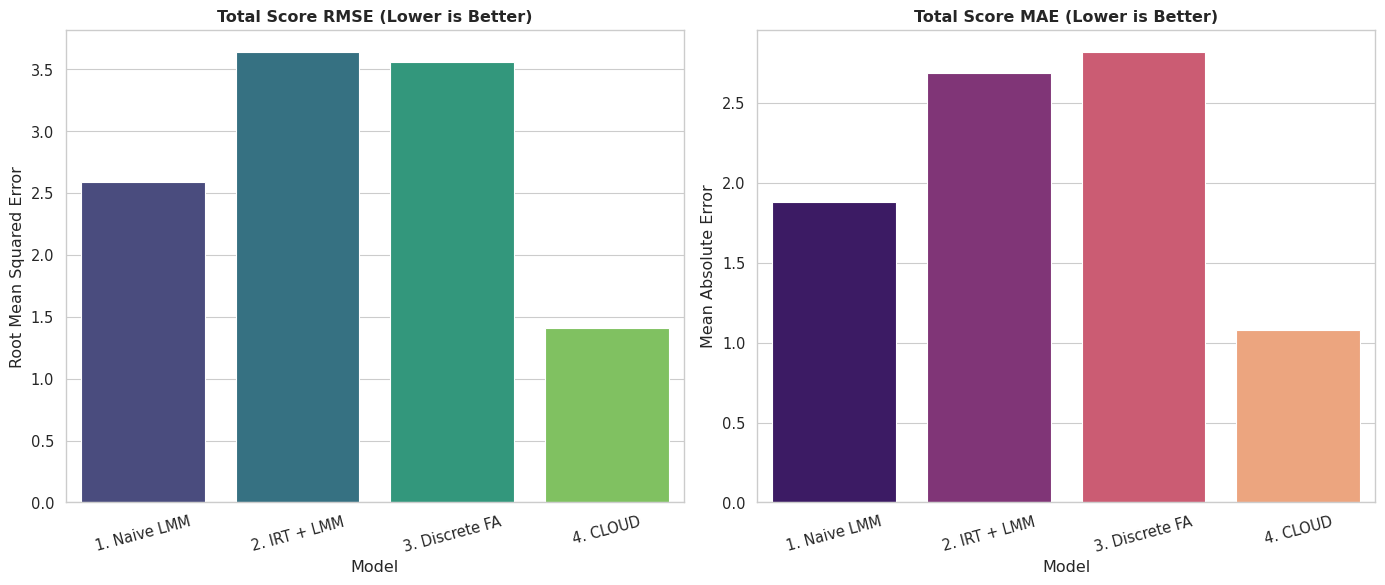

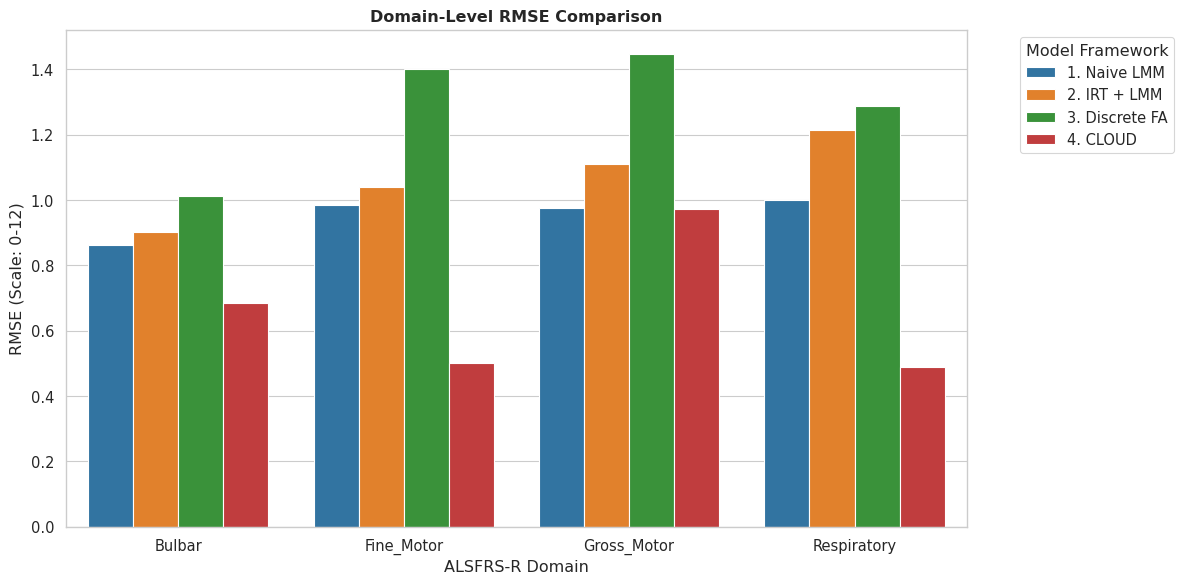

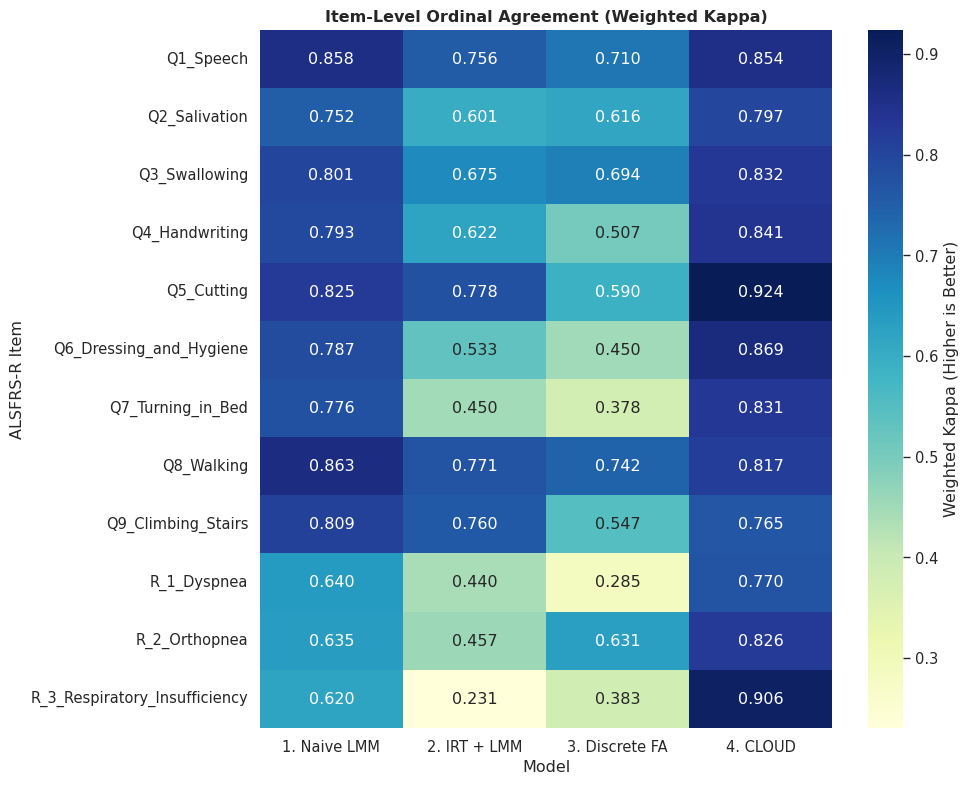

In [2]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, mean_absolute_error, cohen_kappa_score
from scipy.special import expit
from girth import grm_mml
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# ==========================================
# 0. CONFIGURATION & DATA LOADING
# ==========================================
print("=== STARTING MASTER ABLATION PIPELINE ===")
print("Loading data...")

# --- USER INPUTS ---
DATA_FILE = "proact_preprocessed_S1.csv"         # Your patient dataframe
MCMC_FILE = "../raw_results/results_S1_dahlou_ncp_cov_run1.csv" # Your Stan summary output
# -------------------

df = pd.read_csv(DATA_FILE)
df_mcmc = pd.read_csv(MCMC_FILE)

domains = {
    'Bulbar': ['Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing'],
    'Fine_Motor': ['Q4_Handwriting', 'Q5_Cutting', 'Q6_Dressing_and_Hygiene'],
    'Gross_Motor': ['Q7_Turning_in_Bed', 'Q8_Walking', 'Q9_Climbing_Stairs'],
    'Respiratory': ['R_1_Dyspnea', 'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency']
}
all_items = [item for sublist in domains.values() for item in sublist]
scenarios = {'Total Score': all_items, **domains}

# Constants & Covariates
N = len(df)
Nsub = df['subject_id'].nunique()
K = 12
R = 4
p_meas = 3
covariates = 'ALSFRS_Delta + Sex_Female + Treatment_Active + Age_Base'
covariates_ar = 'Time_Since_Last_Visit + Sex_Female + Treatment_Active + Age_Base'

# Data Prep: Sums and Lags
df['Total Score'] = df[all_items].sum(axis=1)
for dom, items in domains.items():
    df[dom] = df[items].sum(axis=1)

df = df.sort_values(by=['subject_id', 'ALSFRS_Delta'])
df['Delta_Lag'] = df.groupby('subject_id')['ALSFRS_Delta'].shift(1)
df['Time_Since_Last_Visit'] = df['ALSFRS_Delta'] - df['Delta_Lag']

# Master Results Container
master_results = []

# ==========================================
# HELPER FUNCTIONS
# ==========================================
def record_metrics(model_name, level, target, actual, expected):
    """Calculates all metrics and appends to master list."""
    rmse = np.sqrt(mean_squared_error(actual, expected))
    mae = mean_absolute_error(actual, expected)
    
    if level == 'Individual Item':
        pred_cat = np.clip(np.round(expected), 0, 4)
        exact = np.mean(pred_cat == actual) * 100
        kappa = cohen_kappa_score(actual, pred_cat, weights='linear')
    else:
        exact, kappa = np.nan, np.nan
        
    master_results.append({
        'Model': model_name, 'Level': level, 'Target': target,
        'RMSE': rmse, 'MAE': mae, 'Exact_Match_%': exact, 'Weighted_Kappa': kappa
    })

def get_irt_expected(theta, discrimination, thresholds):
    """Maps latent theta back to 0-4 scale for GRM."""
    p_ge = [expit(discrimination * (theta - th)) for th in thresholds]
    p4 = p_ge[3]
    p3 = p_ge[2] - p_ge[3]
    p2 = p_ge[1] - p_ge[2]
    p1 = p_ge[0] - p_ge[1]
    p0 = 1.0 - p_ge[0]
    return (0*p0) + (1*p1) + (2*p2) + (3*p3) + (4*p4)

# ==========================================
# 1. BASELINE 1: NAIVE LMM
# ==========================================
print("\n[1/4] Fitting Naive LMM...")
for level, t_list in {'Overall': ['Total Score'], 'Domain': list(domains.keys()), 'Individual Item': all_items}.items():
    for target in t_list:
        formula = f"Q('{target}') ~ {covariates}" if ' ' in target else f"{target} ~ {covariates}"
        try:
            model = smf.mixedlm(formula, data=df, groups=df["subject_id"]).fit(reml=False, disp=False)
            expected = np.clip(model.fittedvalues, 0, 48 if level == 'Overall' else (12 if level == 'Domain' else 4))
            record_metrics('1. Naive LMM', level, target, df[target], expected)
        except: pass

# ==========================================
# 2. BASELINE 2: IRT + LATENT LMM
# ==========================================
print("[2/4] Fitting IRT + Latent LMM...")
for target_name, items in scenarios.items():
    level = 'Overall' if target_name == 'Total Score' else 'Domain'
    irt_data = df[items].astype(int).values.T + 1
    irt_results = grm_mml(irt_data)
    df['theta'] = irt_results['Ability']
    
    try:
        model = smf.mixedlm(f"theta ~ {covariates}", data=df, groups=df["subject_id"]).fit(reml=False, disp=False)
        expected_agg = np.zeros(len(df))
        for i, item in enumerate(items):
            exp_item = get_irt_expected(model.fittedvalues, irt_results['Discrimination'][i], irt_results['Difficulty'][i])
            expected_agg += exp_item
            if level == 'Domain': 
                record_metrics('2. IRT + LMM', 'Individual Item', item, df[item], exp_item)
        record_metrics('2. IRT + LMM', level, target_name, df[target_name], expected_agg)
    except: pass

# ==========================================
# 3. BASELINE 3: DISCRETE-TIME FA
# ==========================================
print("[3/4] Fitting Discrete-Time Factor Analysis...")
for target_name, items in scenarios.items():
    level = 'Overall' if target_name == 'Total Score' else 'Domain'
    fa = FactorAnalyzer(n_factors=1, rotation=None)
    fa.fit(df[items])
    df['Factor'] = fa.transform(df[items])[:, 0]
    
    df['Factor_Lag'] = df.groupby('subject_id')['Factor'].shift(1)
    df_dyn = df.dropna(subset=['Factor_Lag', 'Time_Since_Last_Visit']).copy()
    formula = f"Factor ~ Factor_Lag + {covariates_ar}"
    
    try:
        try:
            model = smf.mixedlm(formula, data=df_dyn, groups=df_dyn["subject_id"])
            fitted_factor = model.fit(method='lbfgs', reml=False, disp=False).fittedvalues
        except:
            fitted_factor = smf.ols(formula, data=df_dyn).fit().fittedvalues
            
        expected_agg = np.zeros(len(df_dyn))
        for i, item in enumerate(items):
            exp_item = np.clip((fitted_factor * fa.loadings_[:, 0][i]) + df_dyn[items].mean().values[i], 0, 4)
            expected_agg += exp_item
            if level == 'Domain':
                record_metrics('3. Discrete FA', 'Individual Item', item, df_dyn[item], exp_item)
        record_metrics('3. Discrete FA', level, target_name, df_dyn[target_name], expected_agg)
    except: pass

# ==========================================
# 4. FINAL MODEL: CLOUD PROCESS
# ==========================================
print("[4/4] Evaluating CLOUD Process (MCMC)...")
def extract_stan(param, shape):
    out = np.zeros(shape)
    for _, r in df_mcmc[df_mcmc['Parameter'].str.contains(rf"^{param}\[", regex=True)].iterrows():
        idx = [int(i)-1 for i in re.search(r'\[(.*?)\]', r['Parameter']).group(1).split(',')]
        if len(idx)==1: out[idx[0]] = r['Estimate']
        elif len(idx)==2: out[idx[0], idx[1]] = r['Estimate']
        elif len(idx)==3: out[idx[0], idx[1], idx[2]] = r['Estimate']
    return out

theta = extract_stan('theta', (K, 4))
lam   = extract_stan('lambda', (K,))
beta  = extract_stan('beta', (K, p_meas))
xi    = extract_stan('xi', (R, N))
b     = extract_stan('b', (Nsub, K))

ID = df['subject_id'].map({s: i+1 for i, s in enumerate(df['subject_id'].unique())}).values
X_m = df[['Sex_Female', 'Treatment_Active', 'Age_Base']].values
actual_scores = df[all_items].values
expected_scores = np.zeros((N, K))

domain_map = {0: [0,1,2], 1: [3,4,5], 2: [6,7,8], 3: [9,10,11]}
for i in range(N):
    sub = ID[i]-1; xm = X_m[i,:]
    for d, items in domain_map.items():
        for k in items:
            eta = np.dot(xm, beta[k]) + lam[k]*xi[d,i] + b[sub,k]
            expected_scores[i,k] = get_irt_expected(eta, 1.0, theta[k])

for k in range(K):
    record_metrics('4. CLOUD', 'Individual Item', all_items[k], actual_scores[:,k], expected_scores[:,k])
for d, items in domain_map.items():
    record_metrics('4. CLOUD', 'Domain', list(domains.keys())[d], actual_scores[:,items].sum(axis=1), expected_scores[:,items].sum(axis=1))
record_metrics('4. CLOUD', 'Overall', 'Total Score', actual_scores.sum(axis=1), expected_scores.sum(axis=1))

# ==========================================
# 5. AGGREGATION & CONSOLE OUTPUT
# ==========================================
print("\n=== PIPELINE COMPLETE. GENERATING REPORTS ===")
df_results = pd.DataFrame(master_results)
df_results['Level'] = pd.Categorical(df_results['Level'], categories=['Overall', 'Domain', 'Individual Item'], ordered=True)
df_results.to_csv("master_ablation_results.csv", index=False)

# Print Total Score Table
pivot_total = df_results[df_results['Target']=='Total Score'].pivot(index='Target', columns='Model', values=['RMSE', 'MAE'])
print("\n--- OVERALL PREDICTIVE ACCURACY ---")
print(pivot_total.to_string(float_format="{:.3f}".format))

# ==========================================
# 6. VISUALIZATIONS (Saved to disk)
# ==========================================
print("\nGenerating visual plots...")

# Plot 1: Total Score RMSE & MAE Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
df_overall = df_results[df_results['Level'] == 'Overall']
sns.barplot(data=df_overall, x='Model', y='RMSE', ax=axes[0], palette='viridis')
axes[0].set_title('Total Score RMSE (Lower is Better)', fontweight='bold')
axes[0].set_ylabel('Root Mean Squared Error')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=df_overall, x='Model', y='MAE', ax=axes[1], palette='magma')
axes[1].set_title('Total Score MAE (Lower is Better)', fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('Fig1_Overall_Metrics.png', dpi=300)

# Plot 2: Domain-Level RMSE
plt.figure(figsize=(12, 6))
df_domain = df_results[df_results['Level'] == 'Domain']
sns.barplot(data=df_domain, x='Target', y='RMSE', hue='Model', palette='tab10')
plt.title('Domain-Level RMSE Comparison', fontweight='bold')
plt.ylabel('RMSE (Scale: 0-12)')
plt.xlabel('ALSFRS-R Domain')
plt.legend(title='Model Framework', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Fig2_Domain_RMSE.png', dpi=300)

# Plot 3: Item-Level Weighted Kappa (Heatmap)
plt.figure(figsize=(10, 8))
df_item = df_results[df_results['Level'] == 'Individual Item']
kappa_pivot = df_item.pivot(index='Target', columns='Model', values='Weighted_Kappa')
sns.heatmap(kappa_pivot, annot=True, cmap='YlGnBu', fmt=".3f", cbar_kws={'label': 'Weighted Kappa (Higher is Better)'})
plt.title('Item-Level Ordinal Agreement (Weighted Kappa)', fontweight='bold')
plt.ylabel('ALSFRS-R Item')
plt.xlabel('Model')
plt.tight_layout()
plt.savefig('Fig3_Item_Kappa_Heatmap.png', dpi=300)

print("\nSuccess! Results saved to 'master_ablation_results.csv'.")
print("Visualizations saved as PNG files in current directory:")
print(" - Fig1_Overall_Metrics.png")
print(" - Fig2_Domain_RMSE.png")
print(" - Fig3_Item_Kappa_Heatmap.png")
print("=========================================")

=== STARTING FULL 6-COVARIATE ABLATION PIPELINE ===
Fitting Baseline Models to extract covariates...


Extracting CLOUD Covariates from MCMC...
Generating Heatmap...
Generating Forest Plots...

TERMINAL EXPORT FOR AI ANALYSIS (Z-SCORES)
Copy and paste the text below back into the chat for interpretation.

---> COVARIATE: SEX_FEMALE <---
Model                          1. Naive LMM  2. Ordinal (IRT)  3. Discrete AR(1)  4. CLOUD
Item                                                                                      
R_3_Respiratory_Insufficiency         2.371             3.689              1.395     2.714
R_2_Orthopnea                         2.540             3.361              2.337     3.049
R_1_Dyspnea                           0.948             1.086              1.966     1.987
Q9_Climbing_Stairs                   -5.754           -13.231             -5.227     1.580
Q8_Walking                           -4.776           -11.103             -1.983     1.721
Q7_Turning_in_Bed                    -2.995            -6.945             -1.478     1.550
Q6_Dressing_and_Hygiene             

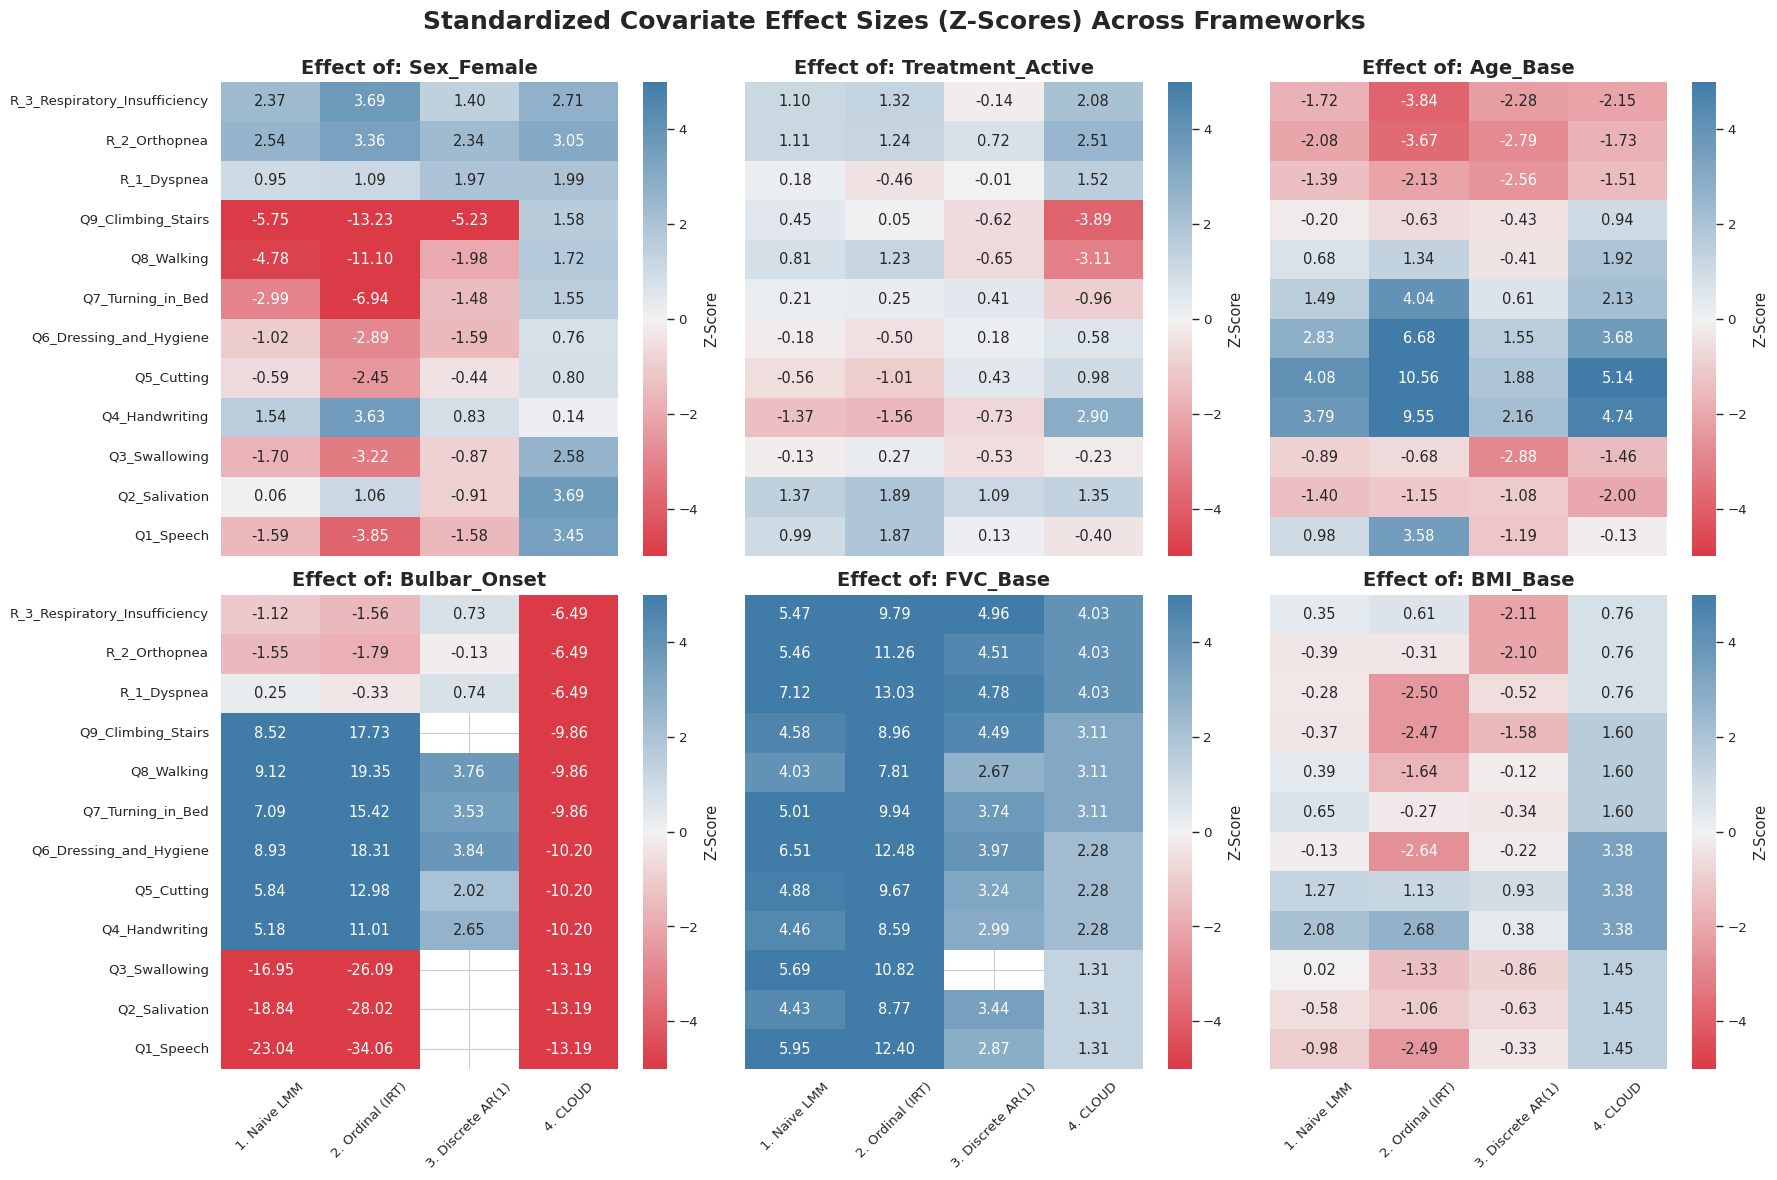

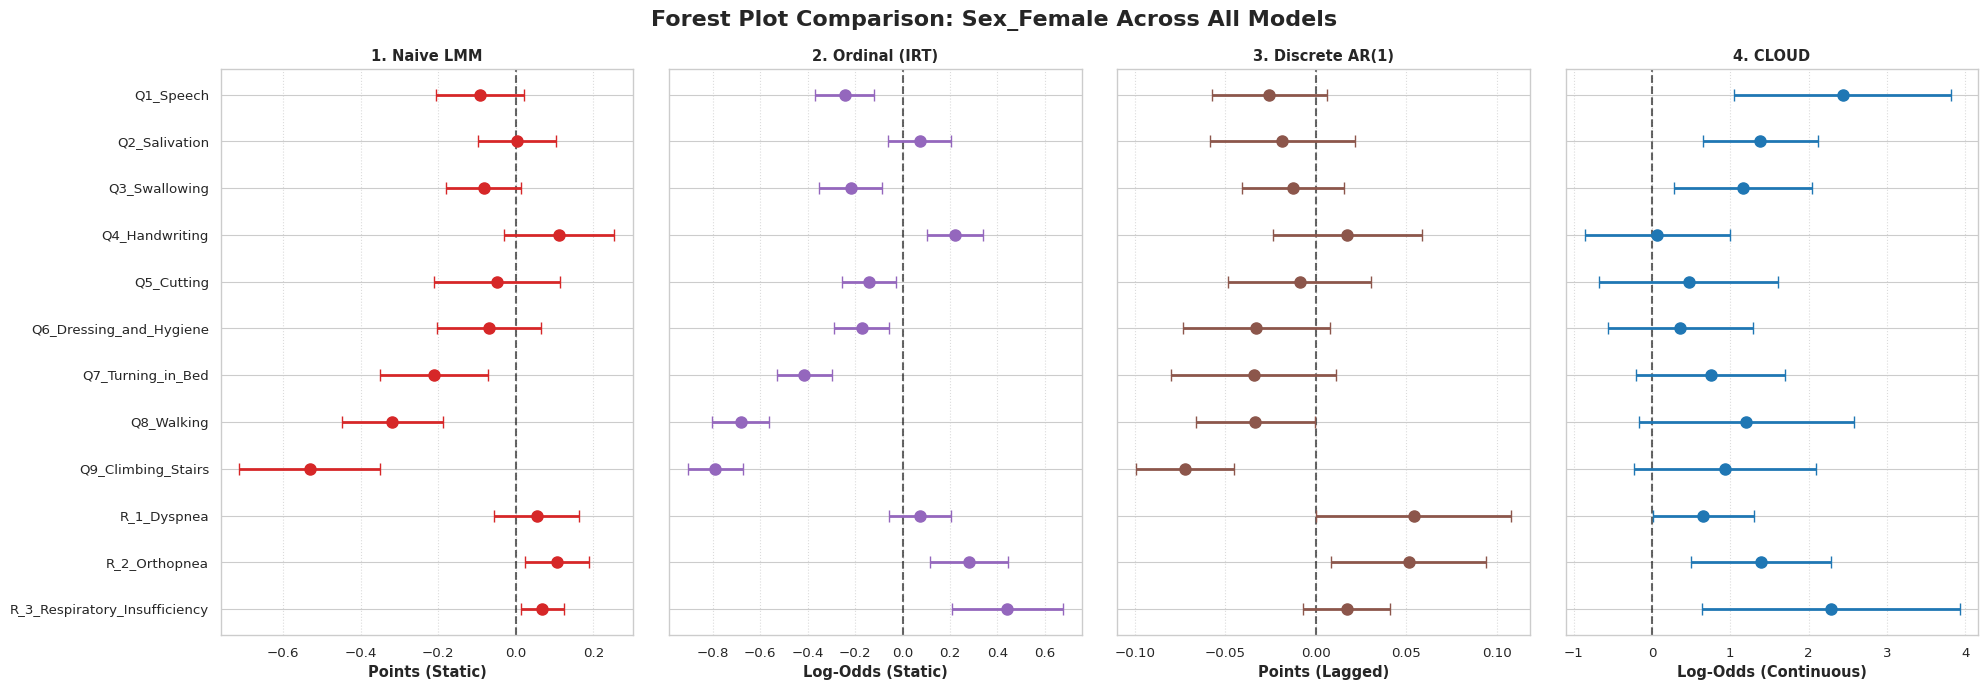

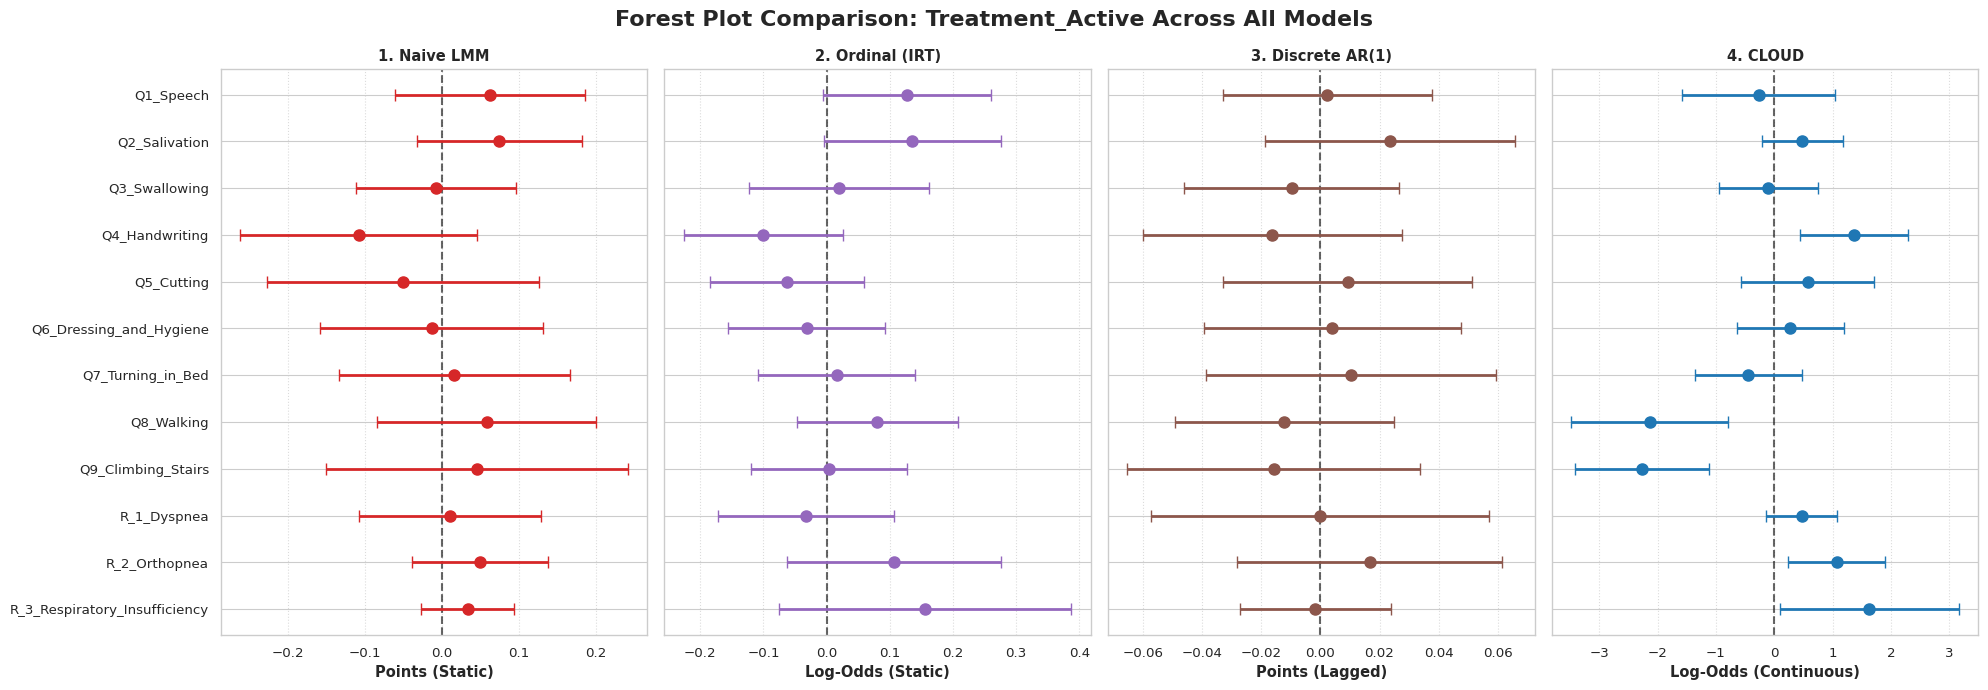

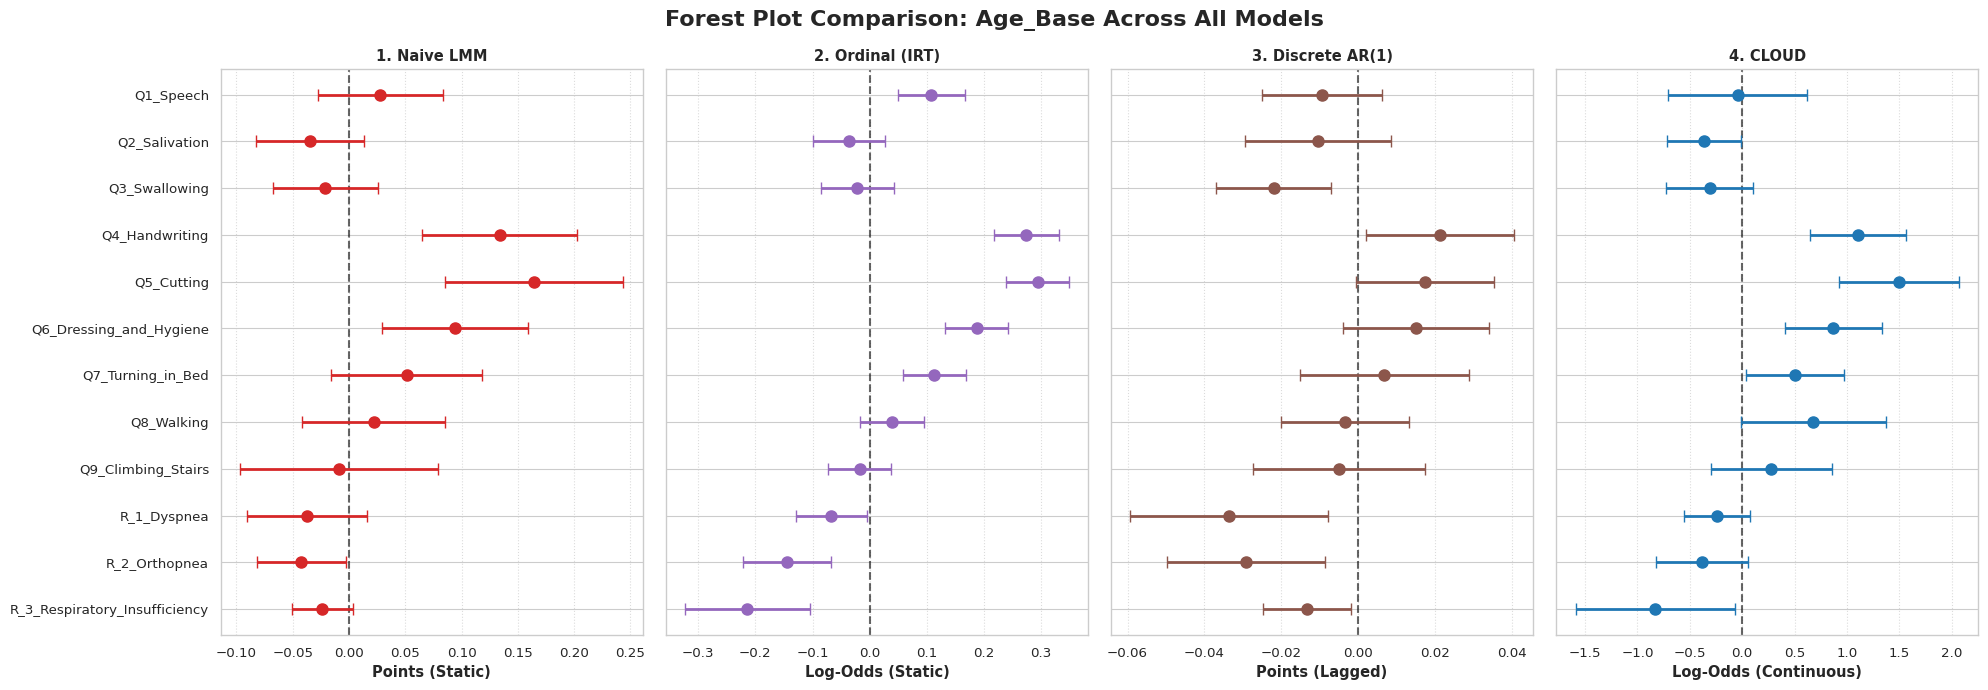

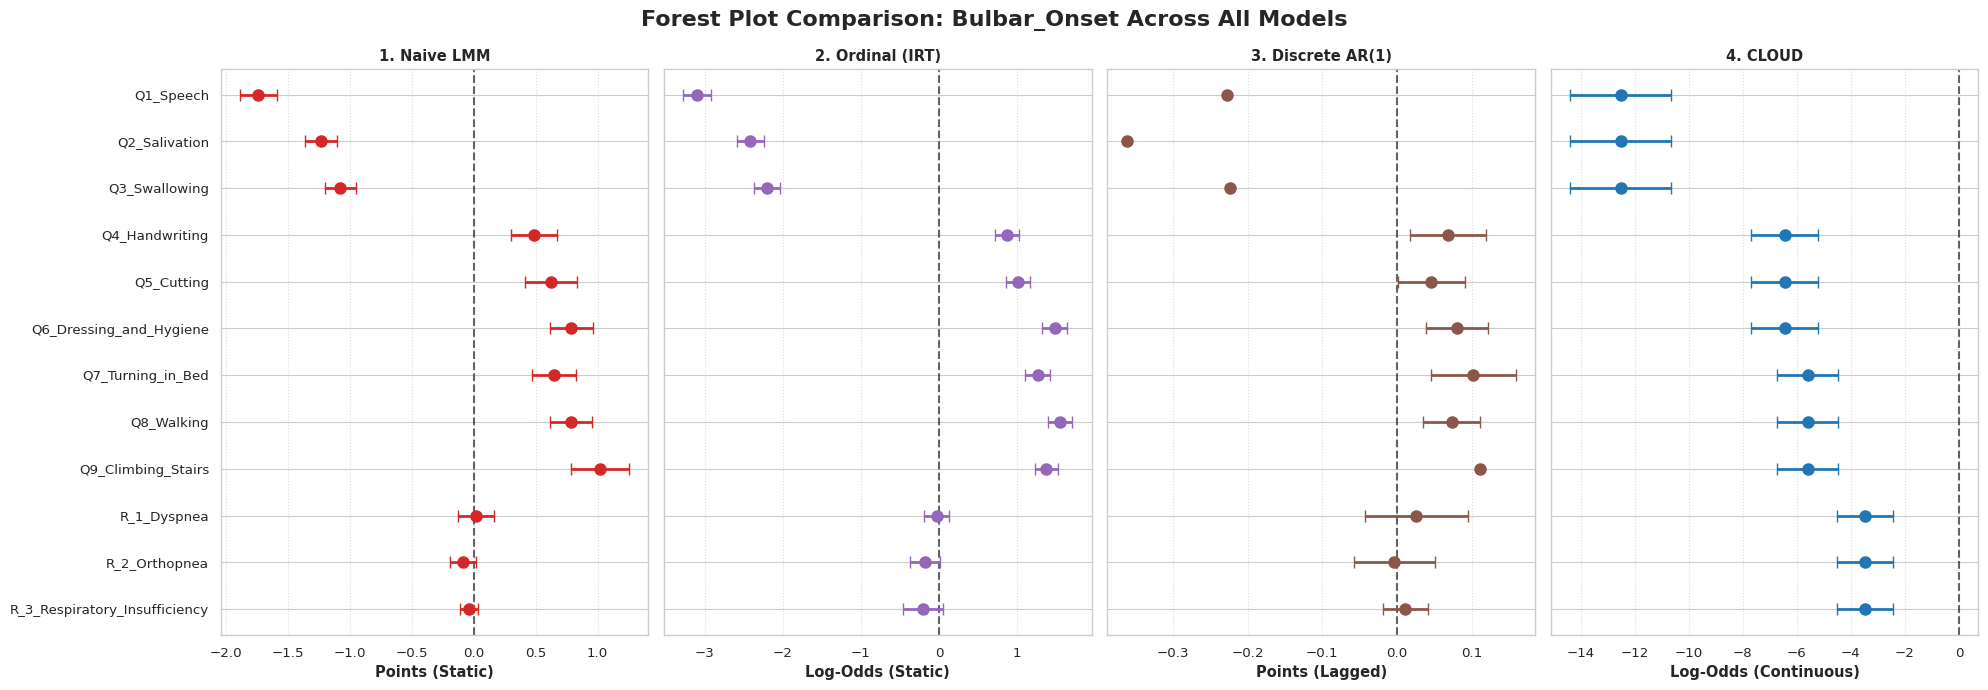

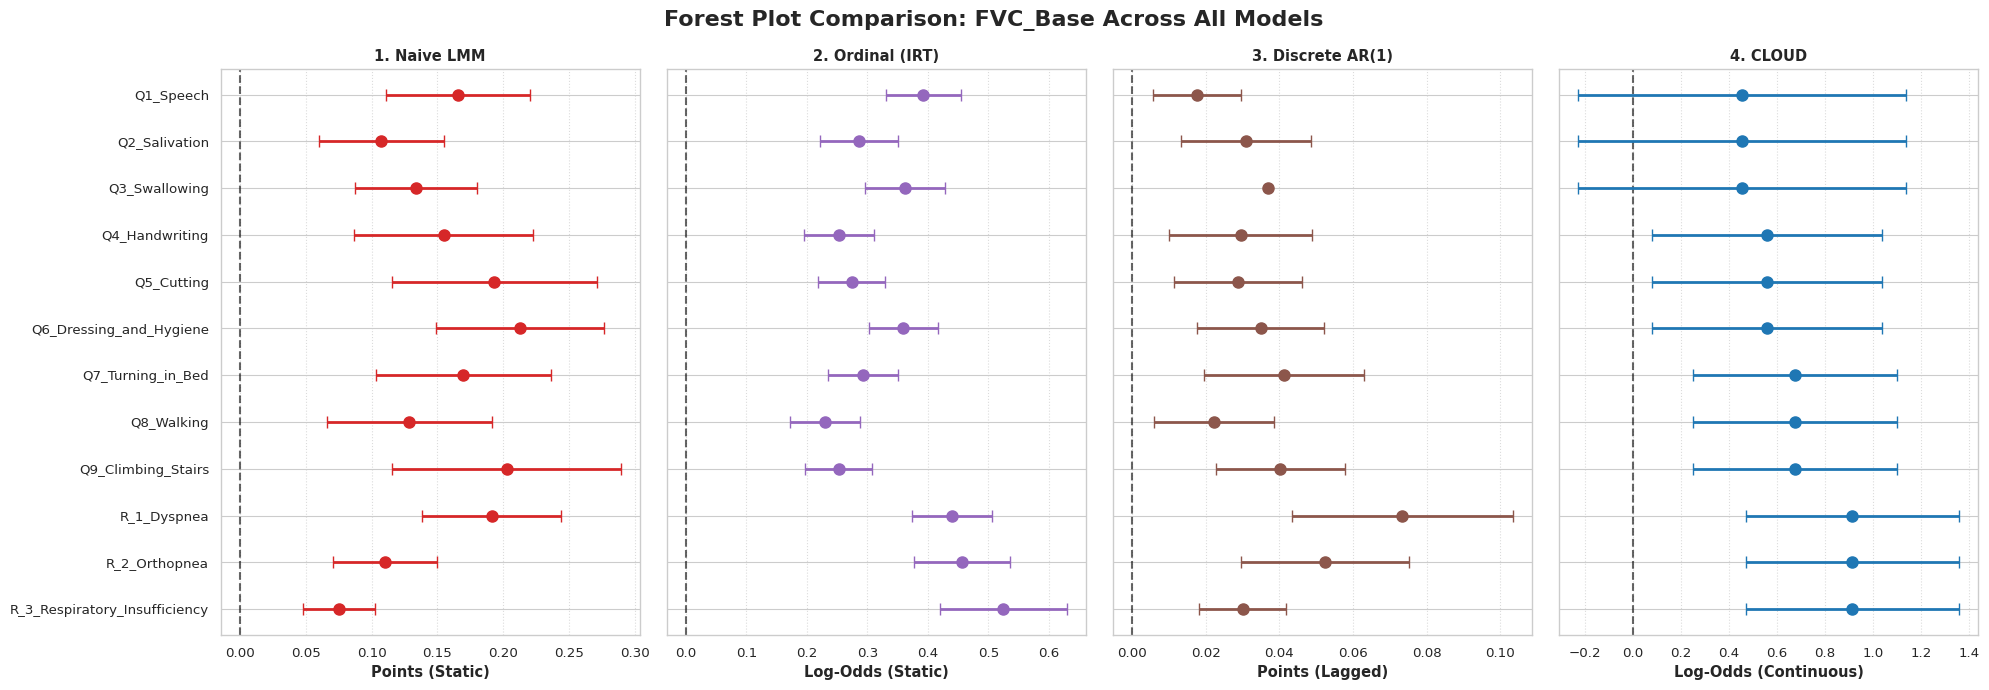

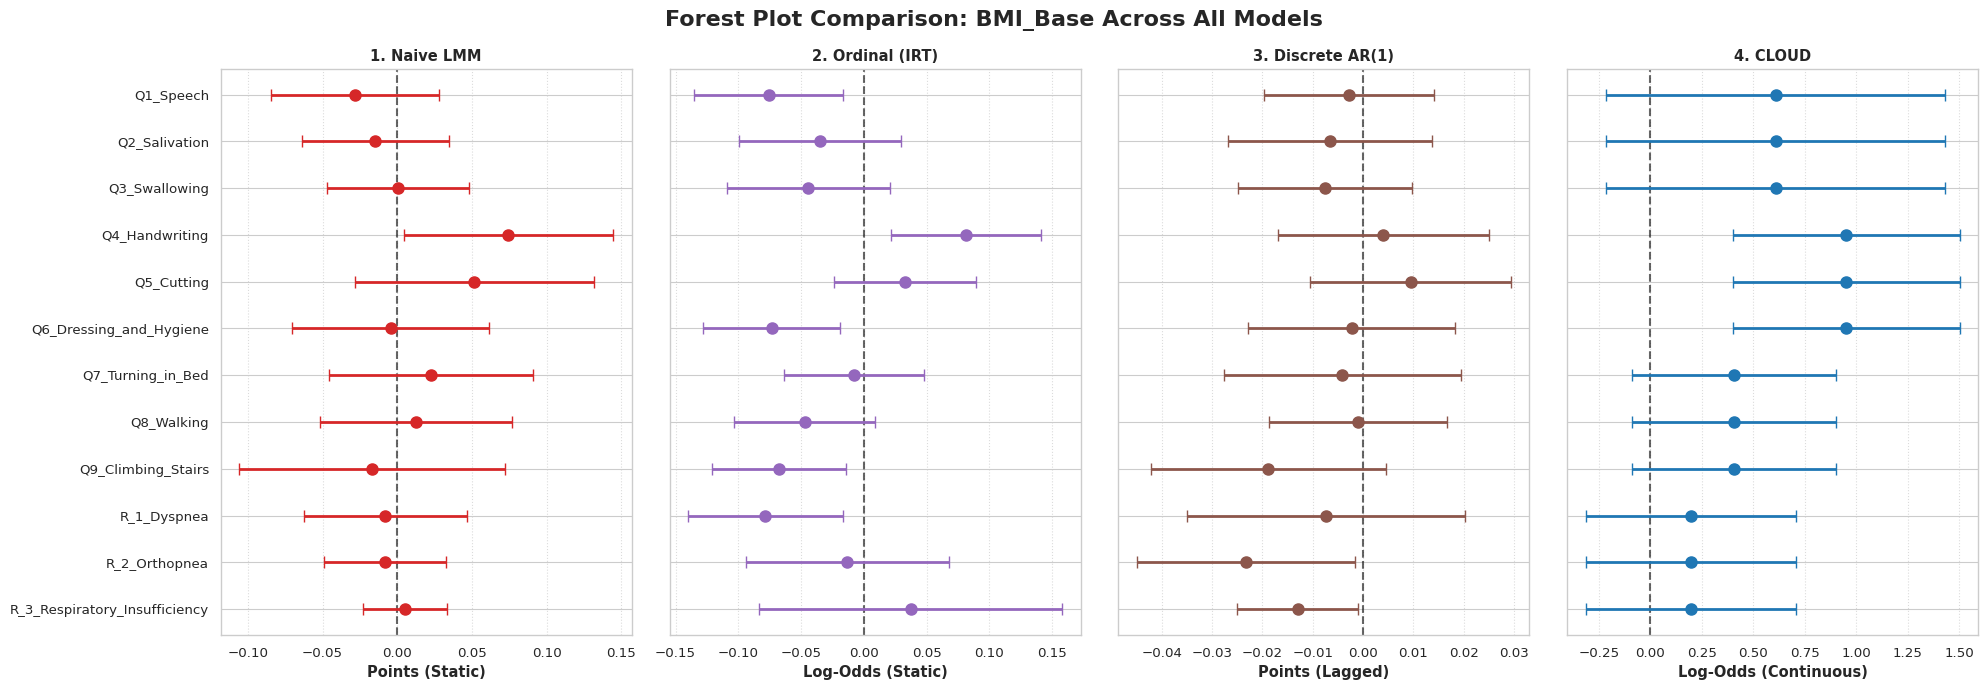

In [9]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# ==========================================
# 0. CONFIGURATION & DATA LOADING
# ==========================================
print("=== STARTING FULL 6-COVARIATE ABLATION PIPELINE ===")

DATA_FILE = "proact_preprocessed_S1.csv"         # UPDATE THIS
MCMC_FILE = "../raw_results/results_S1_dahlou_ncp_cov_run1.csv" # UPDATE THIS

df = pd.read_csv(DATA_FILE)
df_mcmc = pd.read_csv(MCMC_FILE)

all_items = [
    'Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing', 
    'Q4_Handwriting', 'Q5_Cutting', 'Q6_Dressing_and_Hygiene', 
    'Q7_Turning_in_Bed', 'Q8_Walking', 'Q9_Climbing_Stairs', 
    'R_1_Dyspnea', 'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency'
]

target_covariates = [
    'Sex_Female', 'Treatment_Active', 'Age_Base', 
    'Bulbar_Onset', 'FVC_Base', 'BMI_Base'
]
cov_formula_str = " + ".join(target_covariates)
results = []

# ==========================================
# 1-3. EXTRACT BASELINE COVARIATES
# ==========================================
print("Fitting Baseline Models to extract covariates...")

for item in all_items:
    df_item = df[['subject_id', item, 'ALSFRS_Delta'] + target_covariates].dropna().copy()
    
    # --- MODEL 1: NAIVE LMM ---
    formula_m1 = f"{item} ~ {cov_formula_str}"
    try:
        m1 = smf.mixedlm(formula_m1, data=df_item, groups=df_item["subject_id"]).fit(reml=False, disp=False)
    except:
        m1 = smf.ols(formula_m1, data=df_item).fit()
        
    for cov in target_covariates:
        results.append({'Item': item, 'Covariate': cov, 'Model': '1. Naive LMM',
                        'Estimate': m1.params[cov], 'SE': m1.bse[cov], 'Z_Score': m1.tvalues[cov]})

    # --- MODEL 2: ORDINAL (IRT) ---
    try:
        df_item['Item_Cat'] = pd.Categorical(df_item[item].astype(int), ordered=True)
        m2 = OrderedModel(df_item['Item_Cat'], df_item[target_covariates], distr='logit').fit(method='bfgs', disp=False)
        for cov in target_covariates:
            results.append({'Item': item, 'Covariate': cov, 'Model': '2. Ordinal (IRT)',
                            'Estimate': m2.params[cov], 'SE': m2.bse[cov], 'Z_Score': m2.tvalues[cov]})
    except Exception:
        pass 

    # --- MODEL 3: DISCRETE AR(1) ---
    df_item = df_item.sort_values(by=['subject_id', 'ALSFRS_Delta'])
    df_item['Item_Lag'] = df_item.groupby('subject_id')[item].shift(1)
    df_item['Time_Gap'] = df_item.groupby('subject_id')['ALSFRS_Delta'].diff()
    df_lag = df_item.dropna(subset=['Item_Lag', 'Time_Gap'])
    
    formula_m3 = f"{item} ~ Item_Lag + Time_Gap + {cov_formula_str}"
    try:
        m3 = smf.mixedlm(formula_m3, data=df_lag, groups=df_lag["subject_id"]).fit(reml=False, disp=False)
    except:
        m3 = smf.ols(formula_m3, data=df_lag).fit()
        
    for cov in target_covariates:
        results.append({'Item': item, 'Covariate': cov, 'Model': '3. Discrete AR(1)',
                        'Estimate': m3.params[cov], 'SE': m3.bse[cov], 'Z_Score': m3.tvalues[cov]})

# ==========================================
# 4. EXTRACT CLOUD COVARIATES (MCMC)
# ==========================================
print("Extracting CLOUD Covariates from MCMC...")

# Mappings based on your specifications
cov_map_beta = {1: 'Sex_Female', 2: 'Treatment_Active', 3: 'Age_Base'}
cov_map_alpha = {1: 'Bulbar_Onset', 2: 'FVC_Base', 3: 'BMI_Base'}

def extract_mcmc_params(param_prefix, cov_map):
    df_sub = df_mcmc[df_mcmc['Parameter'].str.contains(rf'^{param_prefix}\[', regex=True)].copy()
    if df_sub.empty: return
    
    df_sub[['Dim1', 'Cov_idx']] = df_sub['Parameter'].str.extract(r'\[(\d+),(\d+)\]').astype(int)
    
    # Auto-detect if parameters are Domain-level (4) or Item-level (12)
    is_domain_level = df_sub['Dim1'].max() <= 4
    domain_to_items = {1: [0,1,2], 2: [3,4,5], 3: [6,7,8], 4: [9,10,11]}
    
    for _, row in df_sub.iterrows():
        cov_name = cov_map[int(row['Cov_idx'])]
        est = row['Estimate']
        se = (row['97.5%'] - row['2.5%']) / (2 * 1.96)
        z_score = est / se if se != 0 else 0
        
        if is_domain_level:
            # Map the domain parameter to its 3 constituent items for fair comparison
            for k_idx in domain_to_items[int(row['Dim1'])]:
                results.append({'Item': all_items[k_idx], 'Covariate': cov_name, 'Model': '4. CLOUD',
                                'Estimate': est, 'SE': se, 'Z_Score': z_score})
        else:
            # Direct item mapping
            item_name = all_items[int(row['Dim1']) - 1]
            results.append({'Item': item_name, 'Covariate': cov_name, 'Model': '4. CLOUD',
                            'Estimate': est, 'SE': se, 'Z_Score': z_score})

# Extract both parameter sets
extract_mcmc_params('beta', cov_map_beta)
extract_mcmc_params('alpha_dyn', cov_map_alpha)

# ==========================================
# 5. AGGREGATE AND FORMAT DATA
# ==========================================
df_combined = pd.DataFrame(results)
df_combined['Item'] = pd.Categorical(df_combined['Item'], categories=reversed(all_items), ordered=True)
df_combined['Model'] = pd.Categorical(df_combined['Model'], categories=[
    '1. Naive LMM', '2. Ordinal (IRT)', '3. Discrete AR(1)', '4. CLOUD'
], ordered=True)

df_combined = df_combined.sort_values(['Item', 'Model'])
df_combined.to_csv("master_6covariate_comparison.csv", index=False)

# ==========================================
# 6. VISUALIZATION 1: 2x3 Z-SCORE HEATMAP 
# ==========================================
print("Generating Heatmap...")
fig, axes = plt.subplots(2, 3, figsize=(18, 12), sharey=True, sharex=True)
fig.suptitle("Standardized Covariate Effect Sizes (Z-Scores) Across Frameworks", fontweight='bold', fontsize=18)

axes = axes.flatten()
cmap = sns.diverging_palette(10, 240, as_cmap=True)

for i, cov in enumerate(target_covariates):
    ax = axes[i]
    subset = df_combined[df_combined['Covariate'] == cov]
    if not subset.empty:
        pivot = subset.pivot(index='Item', columns='Model', values='Z_Score')
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap, center=0, 
                    cbar_kws={'label': 'Z-Score'}, ax=ax, vmin=-5, vmax=5)
    ax.set_title(f"Effect of: {cov}", fontweight='bold', fontsize=14)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig("Fig5_Complete_6Covariate_Heatmap.png", dpi=300, bbox_inches='tight')

# ==========================================
# 7. VISUALIZATION 2: DYNAMIC FOREST PLOTS
# ==========================================
print("Generating Forest Plots...")
models = ['1. Naive LMM', '2. Ordinal (IRT)', '3. Discrete AR(1)', '4. CLOUD']
colors = ['#d62728', '#9467bd', '#8c564b', '#1f77b4']
x_labels = ["Points (Static)", "Log-Odds (Static)", "Points (Lagged)", "Log-Odds (Continuous)"]

for cov in target_covariates:
    subset = df_combined[df_combined['Covariate'] == cov]
    if subset.empty: continue
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 7), sharey=True)
    fig.suptitle(f"Forest Plot Comparison: {cov} Across All Models", fontweight='bold', fontsize=16)
    
    for i, model in enumerate(models):
        ax = axes[i]
        mod_data = subset[subset['Model'] == model].sort_values('Item')
        
        ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
        if not mod_data.empty:
            ax.errorbar(mod_data['Estimate'], mod_data['Item'], 
                        xerr=mod_data['SE'] * 1.96, 
                        fmt='o', color=colors[i], ecolor=colors[i], 
                        elinewidth=2, capsize=4, markersize=8)
        ax.set_title(model, fontweight='bold')
        ax.set_xlabel(x_labels[i], fontweight='bold')
        ax.grid(True, axis='x', linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.savefig(f"Fig6_Forest_{cov}.png", dpi=300)

# ==========================================
# 8. CONSOLE OUTPUT FOR LLM TEXT ANALYSIS
# ==========================================
print("\n" + "="*85)
print("TERMINAL EXPORT FOR AI ANALYSIS (Z-SCORES)")
print("Copy and paste the text below back into the chat for interpretation.")
print("="*85)

for cov in target_covariates:
    print(f"\n---> COVARIATE: {cov.upper()} <---")
    subset = df_combined[df_combined['Covariate'] == cov]
    if not subset.empty:
        pivot_z = subset.pivot(index='Item', columns='Model', values='Z_Score')
        print(pivot_z.to_string(float_format="{:.3f}".format, na_rep="NaN"))

print("\n" + "="*85)
print("=== PIPELINE COMPLETE ===")